<a href="https://colab.research.google.com/github/Iamjohnko/Data-science-Project-Portfolio/blob/main/Modeling_Currency_Resilience_in_Commodity_Linked_Economies_A_Machine_Learning_Forecast_of_Ghana%E2%80%99s_Cedi_under_Global_Dollar_Strength.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================
# EDA: Ghana Cedi Resilience Dataset
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [ ]:
# Load dataset
df = pd.read_csv("ghs_currency_resilience_dataset.csv", parse_dates=["date"])
df.set_index("date", inplace=True)

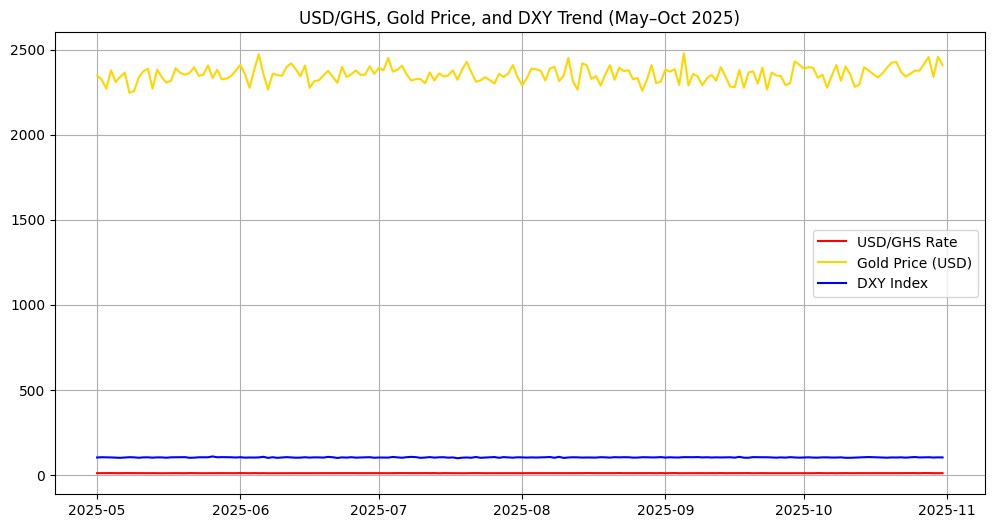

In [ ]:
# 1. Time series trends
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["usd_ghs_rate"], label="USD/GHS Rate", color="red")
plt.plot(df.index, df["gold_price_usd"], label="Gold Price (USD)", color="gold")
plt.plot(df.index, df["dxy_index"], label="DXY Index", color="blue")
plt.title("USD/GHS, Gold Price, and DXY Trend (May–Oct 2025)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 2. Correlation matrix (focused)
focused_corr = df[["usd_ghs_rate", "gold_price_usd", "dxy_index", "gold_to_dxy_ratio"]].corr()
print("\nFocused Correlation Matrix (USD/GHS, Gold, DXY):\n", focused_corr)


Focused Correlation Matrix (USD/GHS, Gold, DXY):
                    usd_ghs_rate  gold_price_usd  dxy_index  gold_to_dxy_ratio
usd_ghs_rate           1.000000        0.008426   0.058869          -0.027179
gold_price_usd         0.008426        1.000000  -0.004960           0.818800
dxy_index              0.058869       -0.004960   1.000000          -0.577878
gold_to_dxy_ratio     -0.027179        0.818800  -0.577878           1.000000


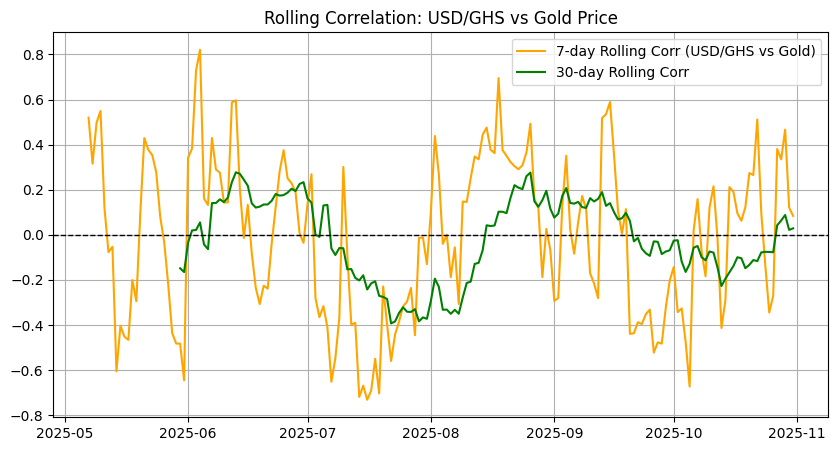

In [ ]:
# 3. Rolling correlations
rolling_corr_7d = df["usd_ghs_rate"].rolling(7).corr(df["gold_price_usd"])
rolling_corr_30d = df["usd_ghs_rate"].rolling(30).corr(df["gold_price_usd"])

plt.figure(figsize=(10, 5))
plt.plot(df.index, rolling_corr_7d, label="7-day Rolling Corr (USD/GHS vs Gold)", color="orange")
plt.plot(df.index, rolling_corr_30d, label="30-day Rolling Corr", color="green")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Rolling Correlation: USD/GHS vs Gold Price")
plt.legend()
plt.grid(True)
plt.show()

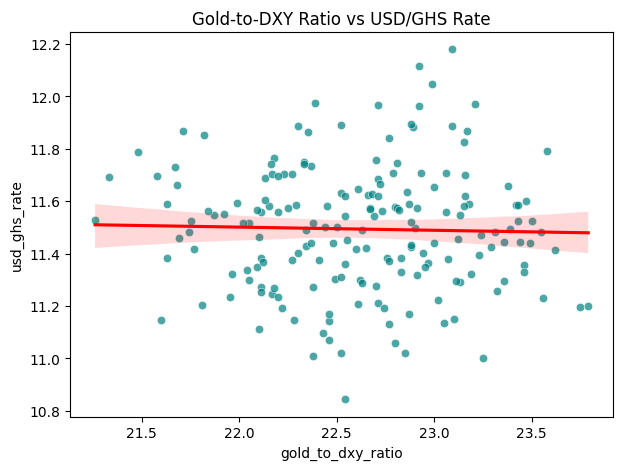

In [ ]:
# 4. Relationship: Gold-to-DXY ratio vs USD/GHS
plt.figure(figsize=(7, 5))
sns.scatterplot(x="gold_to_dxy_ratio", y="usd_ghs_rate", data=df, color="teal", alpha=0.7)
sns.regplot(x="gold_to_dxy_ratio", y="usd_ghs_rate", data=df, scatter=False, color="red")
plt.title("Gold-to-DXY Ratio vs USD/GHS Rate")
plt.show()

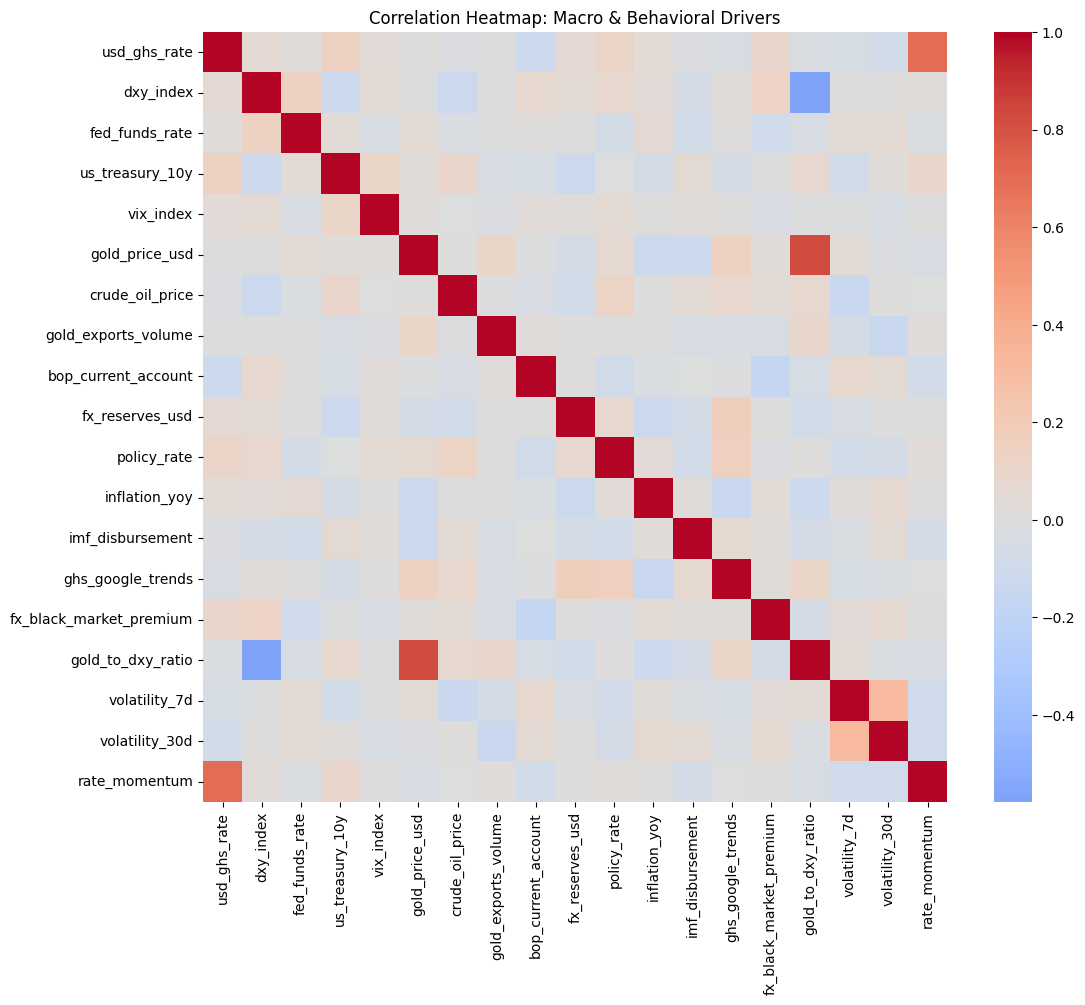

In [ ]:
# Tier 2: Broad EDA (Macro & Behavioral Drivers)
# -----------------------------------

# 5. Correlation heatmap
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: Macro & Behavioral Drivers")
plt.show()

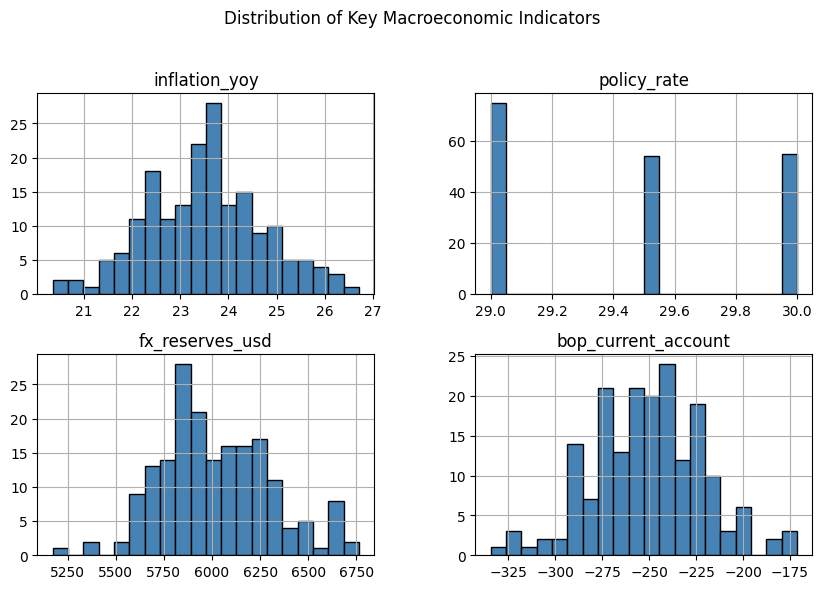

In [ ]:
# 6. Macro distributions
macro_vars = ["inflation_yoy", "policy_rate", "fx_reserves_usd", "bop_current_account"]
df[macro_vars].hist(figsize=(10, 6), bins=20, color="steelblue", edgecolor="black")
plt.suptitle("Distribution of Key Macroeconomic Indicators", y=1.02)
plt.show()

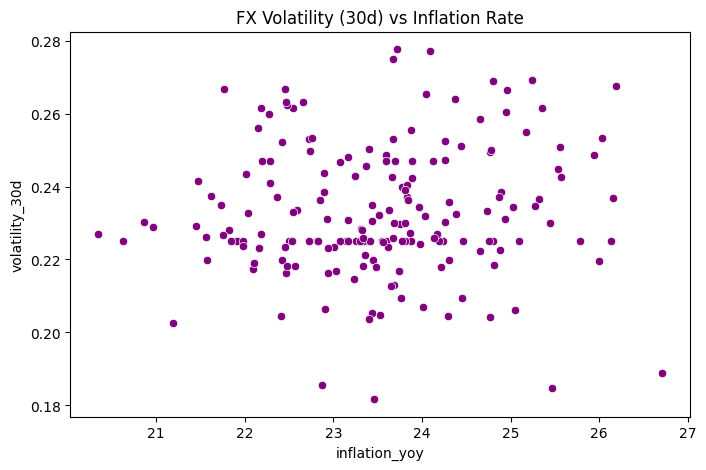

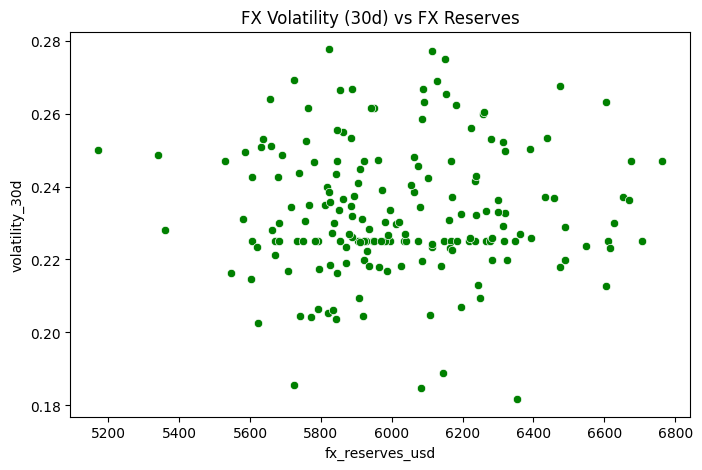

In [ ]:
# 7. Volatility vs macro indicators
plt.figure(figsize=(8, 5))
sns.scatterplot(x="inflation_yoy", y="volatility_30d", data=df, color="purple")
plt.title("FX Volatility (30d) vs Inflation Rate")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x="fx_reserves_usd", y="volatility_30d", data=df, color="green")
plt.title("FX Volatility (30d) vs FX Reserves")
plt.show()

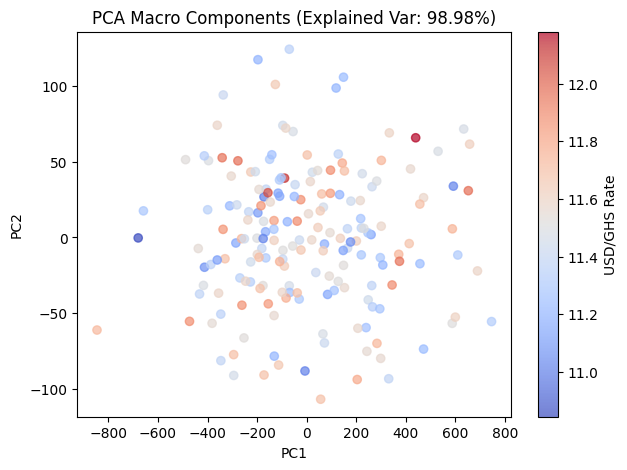

In [ ]:
# 8. Principal Component Analysis (macro structure)
macro_features = ["dxy_index", "gold_price_usd", "crude_oil_price", "inflation_yoy",
                  "policy_rate", "fx_reserves_usd", "bop_current_account"]
X = df[macro_features].dropna()

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(7, 5))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df["usd_ghs_rate"], cmap="coolwarm", alpha=0.7)
plt.colorbar(label="USD/GHS Rate")
plt.title(f"PCA Macro Components (Explained Var: {explained_var.sum():.2%})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:

# 9. Summary Stats
print("\n--- Summary Statistics ---\n")
print(df.describe().T)


--- Summary Statistics ---

                         count         mean         std        min  \
usd_ghs_rate             184.0    11.493451    0.236727    10.8450   
dxy_index                184.0   104.067391    1.415120    99.1400   
fed_funds_rate           184.0     4.989130    0.205502     4.7500   
us_treasury_10y          184.0     4.111957    0.111063     3.8400   
vix_index                184.0    17.538098    1.297106    13.2200   
gold_price_usd           184.0  2353.399457   45.280322  2245.7400   
crude_oil_price          184.0    85.373152    5.687683    72.7200   
gold_exports_volume      184.0  1189.026630  107.085750   861.2000   
bop_current_account      184.0  -250.461033   29.184545  -334.1900   
fx_reserves_usd          184.0  6018.290761  289.430265  5172.1200   
policy_rate              184.0    29.445652    0.417883    29.0000   
inflation_yoy            184.0    23.525543    1.204647    20.3500   
imf_disbursement         184.0    50.543478  112.593511     0

In [ ]:
# 10. Highlight Top Correlations with USD/GHS
corrs = corr["usd_ghs_rate"].sort_values(ascending=False)
print("\nTop Correlations with USD/GHS Rate:\n", corrs)


Top Correlations with USD/GHS Rate:
 usd_ghs_rate               1.000000
rate_momentum              0.694736
us_treasury_10y            0.140128
policy_rate                0.113517
fx_black_market_premium    0.091262
fx_reserves_usd            0.061044
dxy_index                  0.058869
inflation_yoy              0.039822
vix_index                  0.033190
fed_funds_rate             0.015855
gold_price_usd             0.008426
gold_exports_volume       -0.006054
crude_oil_price           -0.017296
imf_disbursement          -0.017774
gold_to_dxy_ratio         -0.027179
ghs_google_trends         -0.045710
volatility_7d             -0.052962
volatility_30d            -0.079289
bop_current_account       -0.109994
Name: usd_ghs_rate, dtype: float64


GHANA CEDI FX RESILIENCE — FULL ANALYST PIPELINE

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests

In [ ]:
# --- LOAD DATA ---
df = pd.read_csv("ghs_currency_resilience_dataset.csv")

# Ensure Date column is in datetime
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace=True)

In [ ]:
# --- Prepare data for the model with new features ---
features_updated = [col for col in df_featured.columns if col != target]
X_featured = df_featured[features_updated]
y_featured = df_featured[target]

# Split data again (after dropping NaNs from feature engineering)
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_featured, y_featured, test_size=0.2, shuffle=False)

# --- Train Model with Updated Features ---
model_featured = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
model_featured.fit(X_train_f, y_train_f)

# --- Evaluate Updated Model ---
y_pred_f = model_featured.predict(X_test_f)
mae_f = mean_absolute_error(y_test_f, y_pred_f)
r2_f = r2_score(y_test_f, y_pred_f)

print(f"\nModel Performance with Feature Engineering — MAE: {mae_f:.4f}, R²: {r2_f:.4f}")


Model Performance with Feature Engineering — MAE: 0.1358, R²: 0.4126


In [ ]:
# --- Feature Engineering Upgrade ---

# Add lagged and rolling features
for col in ['gold_price_usd', 'dxy_index', 'crude_oil_price', 'fx_reserves_usd']:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag3'] = df[col].shift(3)
    df[f'{col}_7d_avg'] = df[col].rolling(7).mean()

# Drop initial NaNs created by lagging and rolling
df_featured = df.dropna()

print("DataFrame with new features:")
display(df_featured.head())

DataFrame with new features:


,usd_ghs_rate,dxy_index,fed_funds_rate,us_treasury_10y,vix_index,gold_price_usd,crude_oil_price,gold_exports_volume,bop_current_account,fx_reserves_usd,...,gold_price_usd_7d_avg,dxy_index_lag1,dxy_index_lag3,dxy_index_7d_avg,crude_oil_price_lag1,crude_oil_price_lag3,crude_oil_price_7d_avg,fx_reserves_usd_lag1,fx_reserves_usd_lag3,fx_reserves_usd_7d_avg
date,,,,,,,,,,,,,,,,,,,,,
2025-05-07,11.895,103.33,4.75,4.08,18.03,2364.35,96.84,1185.6,-270.61,5980.04,...,2333.308571,101.73,103.89,103.588571,90.38,82.70,90.571429,5792.20,5994.50,6014.738571
2025-05-08,11.692,105.28,4.75,4.09,17.52,2245.74,82.88,1279.6,-263.75,6073.58,...,2318.587143,103.33,102.73,103.820000,96.84,93.66,90.340000,5980.04,6265.90,5994.030000
2025-05-09,11.383,104.32,5.00,4.27,20.23,2256.93,83.23,1247.7,-228.03,6348.07,...,2309.257143,105.28,101.73,103.712857,82.88,90.38,89.017143,6073.58,5792.20,6051.227143
2025-05-10,11.636,102.13,5.25,4.34,15.54,2335.01,74.87,972.3,-287.15,5928.21,...,2318.582857,104.32,103.33,103.344286,83.23,96.84,86.365714,6348.07,5980.04,6054.642857
2025-05-11,11.384,104.26,5.25,4.18,17.63,2372.73,87.86,1224.7,-236.72,5784.65,...,2317.774286,102.13,105.28,103.397143,74.87,82.88,87.102857,5928.21,6073.58,6024.664286


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define a grid of hyperparameters to search
param_grid = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

# Initialize GridSearchCV with the XGBRegressor model
grid_search = GridSearchCV(estimator=XGBRegressor(random_state=42),
                           param_grid=param_grid,
                           scoring='r2',  # Use R² as the scoring metric
                           cv=3,         # Use 3-fold cross-validation
                           verbose=1,
                           n_jobs=-1)    # Use all available cores

# Fit GridSearchCV to the featured training data
grid_search.fit(X_train_f, y_train_f)

# Print the best hyperparameters found
print("\nBest hyperparameters found:")
print(grid_search.best_params_)

# Get the best model from the grid search
best_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_best = best_model.predict(X_test_f)
mae_best = mean_absolute_error(y_test_f, y_pred_best)
r2_best = r2_score(y_test_f, y_pred_best)

print(f"\nBest Model Performance (after tuning) — MAE: {mae_best:.4f}, R²: {r2_best:.4f}")

Fitting 3 folds for each of 243 candidates, totalling 729 fits

Best hyperparameters found:
{'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}

Best Model Performance (after tuning) — MAE: 0.1299, R²: 0.4314



Feature Importances (from Tuned XGBoost Model):



,Feature,Importance
17,rate_momentum,0.129657
24,crude_oil_price_lag1,0.050667
20,gold_price_usd_7d_avg,0.046894
28,fx_reserves_usd_lag3,0.042395
15,volatility_7d,0.040293
14,gold_to_dxy_ratio,0.038938
19,gold_price_usd_lag3,0.038622
13,fx_black_market_premium,0.037552
25,crude_oil_price_lag3,0.037379
10,inflation_yoy,0.034317


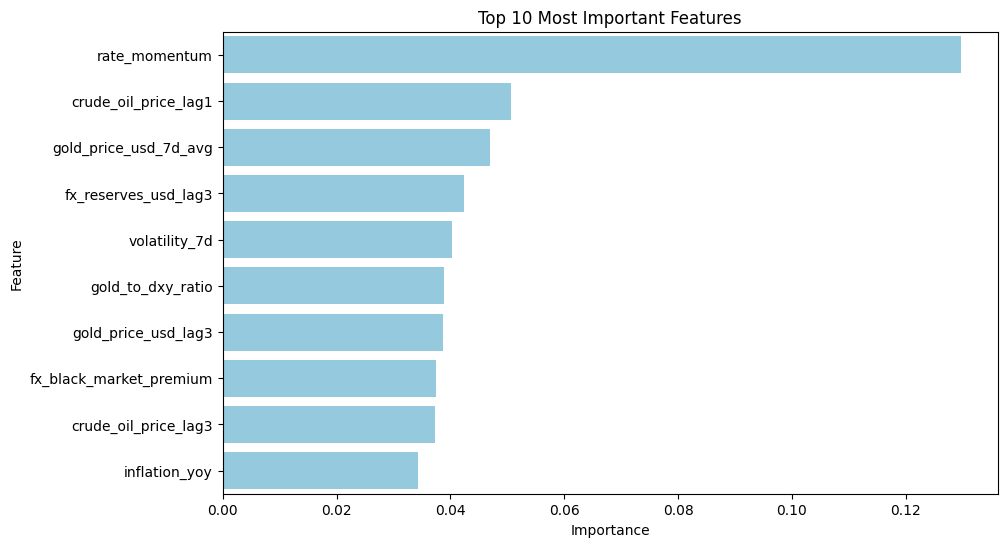

In [ ]:
# --- Feature Importance Analysis ---
importance = best_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_featured.columns, 'Importance': importance})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

print("\nFeature Importances (from Tuned XGBoost Model):\n")
display(feature_importance_df)

# Optional: Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), color='skyblue')
plt.title("Top 10 Most Important Features")
plt.show()

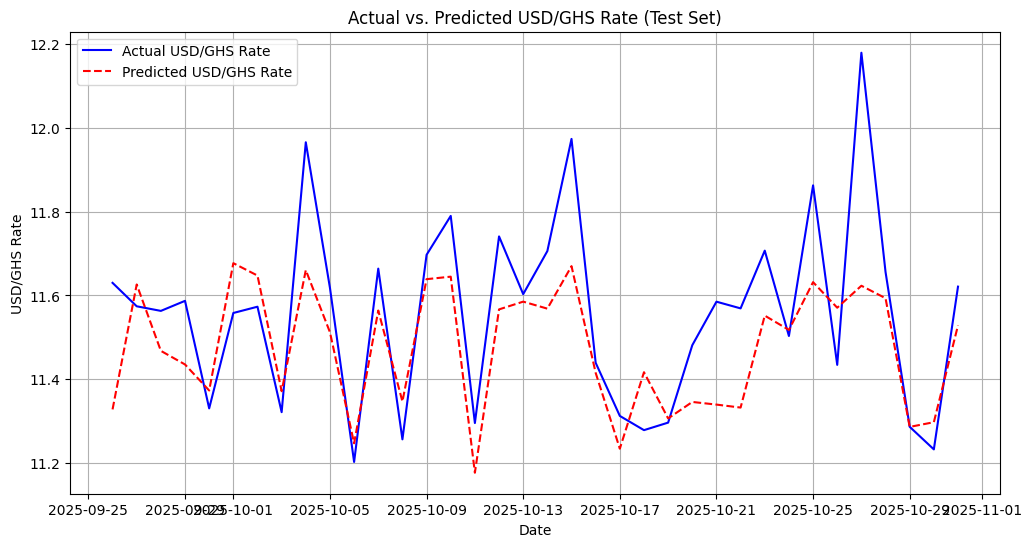

In [ ]:
# --- Visualize Predictions vs Actuals ---
plt.figure(figsize=(12, 6))
plt.plot(y_test_f.index, y_test_f, label='Actual USD/GHS Rate', color='blue')
plt.plot(y_test_f.index, y_pred_best, label='Predicted USD/GHS Rate', color='red', linestyle='--')
plt.title('Actual vs. Predicted USD/GHS Rate (Test Set)')
plt.xlabel('Date')
plt.ylabel('USD/GHS Rate')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# --- Granger Causality Tests ---

# Select variables to test against USD/GHS rate
# Exclude 'rate_momentum' and volatility features as they are derived from usd_ghs_rate
variables_to_test = ['gold_price_usd', 'dxy_index', 'crude_oil_price', 'fed_funds_rate',
                     'fx_reserves_usd', 'gold_exports_volume', 'inflation_yoy',
                     'policy_rate', 'bop_current_account', 'imf_disbursement',
                     'ghs_google_trends', 'fx_black_market_premium', 'gold_to_dxy_ratio']

print("\n--- Granger Causality Test Results (Testing if variable 'Granger-causes' USD/GHS) ---\n")

# Perform Granger Causality test for each variable
for var in variables_to_test:
    try:
        # Test for Granger causality up to 3 lags
        gc_test_result = grangercausalitytests(df[[var, 'usd_ghs_rate']].dropna(), maxlag=3, verbose=False)
        # Extract p-value for the overall test (null hypothesis: var does NOT Granger-cause usd_ghs_rate)
        p_value = gc_test_result[3][0]['ssr_ftest'][1] # Using F-test p-value for lag 3

        print(f"Testing '{var}' Granger-causes 'usd_ghs_rate' (up to 3 lags):")
        if p_value < 0.05:
            print(f"  Result: Statistically Significant (p-value = {p_value:.4f}) - Suggests '{var}' may help predict 'usd_ghs_rate'.")
        else:
            print(f"  Result: Not Statistically Significant (p-value = {p_value:.4f}) - Insufficient evidence that '{var}' helps predict 'usd_ghs_rate'.")
    except Exception as e:
        print(f"  Could not perform Granger Causality test for '{var}': {e}")


--- Granger Causality Test Results (Testing if variable 'Granger-causes' USD/GHS) ---

Testing 'gold_price_usd' Granger-causes 'usd_ghs_rate' (up to 3 lags):
  Result: Not Statistically Significant (p-value = 0.9247) - Insufficient evidence that 'gold_price_usd' helps predict 'usd_ghs_rate'.
Testing 'dxy_index' Granger-causes 'usd_ghs_rate' (up to 3 lags):
  Result: Not Statistically Significant (p-value = 0.2296) - Insufficient evidence that 'dxy_index' helps predict 'usd_ghs_rate'.
Testing 'crude_oil_price' Granger-causes 'usd_ghs_rate' (up to 3 lags):
  Result: Not Statistically Significant (p-value = 0.7999) - Insufficient evidence that 'crude_oil_price' helps predict 'usd_ghs_rate'.
Testing 'fed_funds_rate' Granger-causes 'usd_ghs_rate' (up to 3 lags):
  Result: Not Statistically Significant (p-value = 0.1582) - Insufficient evidence that 'fed_funds_rate' helps predict 'usd_ghs_rate'.
Testing 'fx_reserves_usd' Granger-causes 'usd_ghs_rate' (up to 3 lags):
  Result: Not Statistica

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul

In [ ]:
# --- Granger Causality Tests with Different Lags ---

variables_to_retest = ['gold_exports_volume', 'bop_current_account', 'gold_price_usd', 'dxy_index']
max_lags_to_test = [1, 2, 3, 4, 5] # Test up to 5 lags

print("\n--- Granger Causality Test Results (Testing if variable 'Granger-causes' USD/GHS at different lags) ---\n")

for var in variables_to_retest:
    print(f"Testing '{var}' Granger-causes 'usd_ghs_rate':")
    for maxlag in max_lags_to_test:
        try:
            gc_test_result = grangercausalitytests(df[[var, 'usd_ghs_rate']].dropna(), maxlag=maxlag, verbose=False)
            # Extract p-value for the overall test (null hypothesis: var does NOT Granger-cause usd_ghs_rate)
            # Use the p-value for the specified maxlag
            p_value = gc_test_result[maxlag][0]['ssr_ftest'][1]

            print(f"  Lag {maxlag}: p-value = {p_value:.4f}", end="")
            if p_value < 0.05:
                 print(" - Statistically Significant")
            else:
                 print(" - Not Statistically Significant")

        except Exception as e:
            print(f"  Lag {maxlag}: Could not perform test - {e}")
    print("-" * 30) # Separator for readability


--- Granger Causality Test Results (Testing if variable 'Granger-causes' USD/GHS at different lags) ---

Testing 'gold_exports_volume' Granger-causes 'usd_ghs_rate':
  Lag 1: p-value = 0.0225 - Statistically Significant
  Lag 2: p-value = 0.0323 - Statistically Significant
  Lag 3: p-value = 0.0367 - Statistically Significant
  Lag 4: p-value = 0.0703 - Not Statistically Significant
  Lag 5: p-value = 0.0328 - Statistically Significant
------------------------------
Testing 'bop_current_account' Granger-causes 'usd_ghs_rate':
  Lag 1: p-value = 0.0043 - Statistically Significant
  Lag 2: p-value = 0.0034 - Statistically Significant
  Lag 3: p-value = 0.0093 - Statistically Significant
  Lag 4: p-value = 0.0096 - Statistically Significant
  Lag 5: p-value = 0.0165 - Statistically Significant
------------------------------
Testing 'gold_price_usd' Granger-causes 'usd_ghs_rate':
  Lag 1: p-value = 0.9684 - Not Statistically Significant
  Lag 2: p-value = 0.7905 - Not Statistically Signif

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul

In [ ]:
# --- Refined Feature Engineering ---

# Start with a fresh copy to avoid accumulating features from previous steps
df_refined_features = df.copy()

# Add lagged features for important variables identified by feature importance and Granger Causality
important_vars = ['usd_ghs_rate', 'gold_exports_volume', 'bop_current_account'] # Include target for rate_momentum

for col in important_vars:
    # Add relevant lags based on Granger Causality (e.g., up to lag 5 for those that showed significance)
    for lag in range(1, 6):
        df_refined_features[f'{col}_lag{lag}'] = df_refined_features[col].shift(lag)

# Add rolling features for important variables
for col in important_vars:
    df_refined_features[f'{col}_7d_avg'] = df_refined_features[col].rolling(7).mean()
    df_refined_features[f'{col}_30d_avg'] = df_refined_features[col].rolling(30).mean()

# Keep other original features that were in the best performing model's features
# Exclude the original 'rate_momentum', 'volatility_7d', 'volatility_30d' as they might be recalculated or redundant
original_features_to_keep = [col for col in df.columns if col not in important_vars + ['rate_momentum', 'volatility_7d', 'volatility_30d', 'gold_to_dxy_ratio']]
for col in original_features_to_keep:
     if col not in df_refined_features.columns: # Avoid adding if already added as lagged/rolling
            df_refined_features[col] = df[col]

# Recreate rate_momentum based on the target variable
df_refined_features['rate_momentum'] = df_refined_features['usd_ghs_rate'].diff(periods=1)


# Drop rows with NaN values created by lagging and rolling
df_refined_features.dropna(inplace=True)

print("DataFrame with refined features:")
display(df_refined_features.head())
print("\nShape of DataFrame with refined features:", df_refined_features.shape)

DataFrame with refined features:


,usd_ghs_rate,dxy_index,fed_funds_rate,us_treasury_10y,vix_index,gold_price_usd,crude_oil_price,gold_exports_volume,bop_current_account,fx_reserves_usd,...,bop_current_account_lag2,bop_current_account_lag3,bop_current_account_lag4,bop_current_account_lag5,usd_ghs_rate_7d_avg,usd_ghs_rate_30d_avg,gold_exports_volume_7d_avg,gold_exports_volume_30d_avg,bop_current_account_7d_avg,bop_current_account_30d_avg
date,,,,,,,,,,,,,,,,,,,,,
2025-05-30,11.427,104.98,5.00,4.02,13.22,2344.80,92.90,1175.0,-242.22,6183.24,...,-220.72,-253.71,-258.27,-295.28,11.374143,11.453000,1207.557143,1211.143333,-253.431429,-252.994000
2025-05-31,11.350,103.53,5.25,4.15,17.07,2375.76,89.76,1250.3,-226.21,5619.09,...,-250.90,-220.72,-253.71,-258.27,11.403571,11.443867,1208.200000,1211.723333,-249.615714,-251.006667
2025-06-01,11.963,105.14,4.75,4.17,17.79,2409.71,99.73,1163.9,-213.17,5677.96,...,-242.22,-250.90,-220.72,-253.71,11.489143,11.460467,1188.342857,1209.203333,-237.885714,-250.292000
2025-06-02,11.497,102.84,4.75,3.98,16.82,2354.83,82.95,1446.8,-253.69,5817.80,...,-226.21,-242.22,-250.90,-220.72,11.484714,11.454967,1215.457143,1219.366667,-237.231429,-249.027000
2025-06-03,11.236,103.64,4.75,3.93,17.23,2275.01,85.38,1010.8,-247.17,6488.80,...,-213.17,-226.21,-242.22,-250.90,11.488143,11.433467,1196.542857,1216.046667,-236.297143,-248.170333



Shape of DataFrame with refined features: (155, 52)


In [ ]:
# --- Prepare data for the model with refined features ---
target = 'usd_ghs_rate' # Ensure target is defined if not already in this cell's scope
features_refined = [col for col in df_refined_features.columns if col != target]
X_refined = df_refined_features[features_refined]
y_refined = df_refined_features[target]

# Split data
X_train_refined, X_test_refined, y_train_refined, y_test_refined = train_test_split(X_refined, y_refined, test_size=0.2, shuffle=False)

# --- Train Model with Refined Features ---
model_refined = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42) # Using the same base parameters as before
model_refined.fit(X_train_refined, y_train_refined)

# --- Evaluate Refined Model ---
y_pred_refined = model_refined.predict(X_test_refined)
mae_refined = mean_absolute_error(y_test_refined, y_pred_refined)
r2_refined = r2_score(y_test_refined, y_pred_refined)

print(f"\nModel Performance with Refined Feature Engineering — MAE: {mae_refined:.4f}, R²: {r2_refined:.4f}")


Model Performance with Refined Feature Engineering — MAE: 0.0826, R²: 0.7852



Feature Importances (from Refined XGBoost Model):



,Feature,Importance
17,rate_momentum,0.242812
30,usd_ghs_rate_lag1,0.095894
11,imf_disbursement,0.072474
15,volatility_7d,0.057276
40,bop_current_account_lag1,0.054774
31,usd_ghs_rate_lag2,0.051564
27,fx_reserves_usd_lag1,0.041669
45,usd_ghs_rate_7d_avg,0.033466
44,bop_current_account_lag5,0.031404
41,bop_current_account_lag2,0.026361


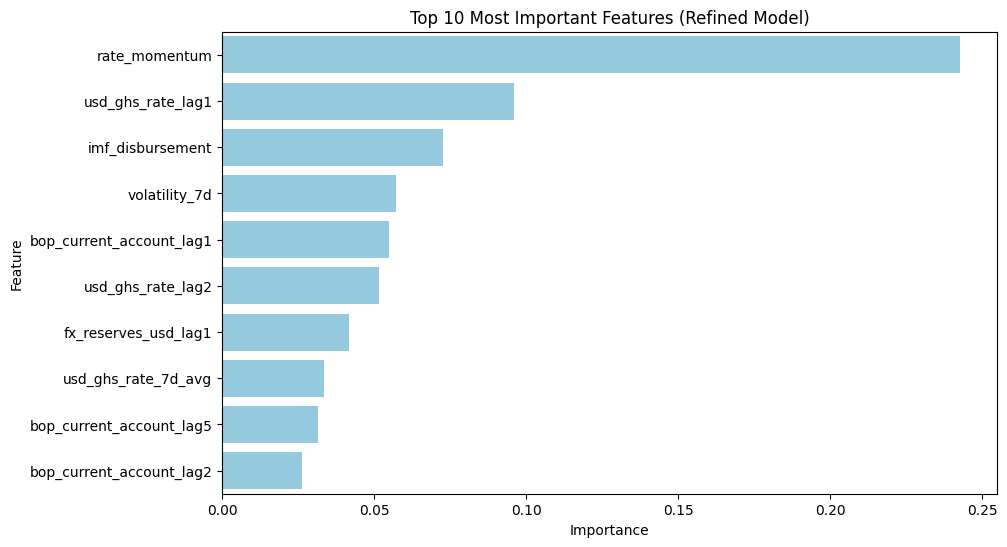

In [ ]:
# --- Feature Importance Analysis (Refined Model) ---
importance_refined = model_refined.feature_importances_
feature_importance_df_refined = pd.DataFrame({'Feature': X_refined.columns, 'Importance': importance_refined})
feature_importance_df_refined = feature_importance_df_refined.sort_values('Importance', ascending=False)

print("\nFeature Importances (from Refined XGBoost Model):\n")
display(feature_importance_df_refined)

# Optional: Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_refined.head(10), color='skyblue')
plt.title("Top 10 Most Important Features (Refined Model)")
plt.show()

In [ ]:
# 3️⃣ CAUSAL SIMULATION & WHAT-IF ANALYSIS
# ============================================

# --- Granger Causality Test ---
print("Granger Causality: Does Gold cause GHS movement?")
grangercausalitytests(df[['gold_price_usd', 'usd_ghs_rate']].dropna(), maxlag=5)

print("Granger Causality: Does DXY cause GHS movement?")
grangercausalitytests(df[['dxy_index', 'usd_ghs_rate']].dropna(), maxlag=5)

# --- What-if Simulation ---
def simulate_scenario(gold_change=0, dxy_change=0, fed_change=0.0):
    """Simulate what-if scenarios for USD/GHS using the refined model"""
    # Use the last row of the refined features DataFrame for the latest values
    latest = X_refined.iloc[-1].copy()

    # Apply changes to the relevant features (using correct column names)
    # Need to handle potential lagged/rolling features derived from these
    # For simplicity, we'll adjust the base features and re-calculate derived ones if needed
    # A more robust approach would involve generating a new row based on the scenario changes
    # and then applying the same feature engineering steps as used for X_refined

    # For this simulation, let's assume we adjust the *current* values and see the impact
    # This is a simplification and might not fully reflect the model's behavior with lagged features
    # A proper simulation would involve creating a new data point with lagged values
    # based on the scenario.

    # Let's assume we are changing the *latest* values and seeing the immediate predicted impact
    # We'll need to map the original feature names to the refined feature names if they are different
    # Based on X_refined, the original names are still present.

    if 'gold_price_usd' in latest.index:
        latest['gold_price_usd'] *= (1 + gold_change)
    if 'dxy_index' in latest.index:
        latest['dxy_index'] *= (1 + dxy_change)
    if 'fed_funds_rate' in latest.index:
        latest['fed_funds_rate'] += fed_change

    # Note: This simplified simulation does NOT update lagged or rolling features based on the scenario changes.
    # For a more accurate simulation, you would need to generate a new row of data reflecting the changes
    # and then apply the feature engineering steps used to create X_refined to that new row.
    # For demonstrating the structure, we'll proceed with this simplification.

    # Predict using the refined model
    # The model expects features in the same order and with the same names as X_refined.columns
    # Ensure the 'latest' Series has all the required features, even if their values aren't changed
    # We need to align the columns of 'latest' with X_refined.columns

    # Create a DataFrame with a single row for prediction, ensuring columns match X_refined
    latest_df = pd.DataFrame([latest], index=[X_refined.index[-1]])
    latest_df = latest_df.reindex(columns=X_refined.columns, fill_value=0) # Ensure all columns are present

    prediction = model_refined.predict(latest_df)[0] # Use the refined model

    print(f"\nScenario Simulation:")
    print(f"Gold {gold_change*100:+.1f}%, DXY {dxy_change*100:+.1f}%, Fed Rate {fed_change:+.2f}")
    print(f"Predicted USD/GHS: {prediction:.4f}") # Increased precision

    return prediction

# Example Scenarios
simulate_scenario(gold_change=0.05, dxy_change=-0.02)  # Gold up 5%, DXY down 2%
simulate_scenario(gold_change=-0.03, dxy_change=0.04)  # Gold down 3%, DXY up 4%
simulate_scenario(fed_change=0.25) # Fed Rate up 0.25%

Granger Causality: Does Gold cause GHS movement?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0016  , p=0.9684  , df_denom=180, df_num=1
ssr based chi2 test:   chi2=0.0016  , p=0.9681  , df=1
likelihood ratio test: chi2=0.0016  , p=0.9681  , df=1
parameter F test:         F=0.0016  , p=0.9684  , df_denom=180, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.2354  , p=0.7905  , df_denom=177, df_num=2
ssr based chi2 test:   chi2=0.4840  , p=0.7850  , df=2
likelihood ratio test: chi2=0.4834  , p=0.7853  , df=2
parameter F test:         F=0.2354  , p=0.7905  , df_denom=177, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.1576  , p=0.9247  , df_denom=174, df_num=3
ssr based chi2 test:   chi2=0.4917  , p=0.9207  , df=3
likelihood ratio test: chi2=0.4910  , p=0.9209  , df=3
parameter F test:         F=0.1576  , p=0.9247  , df_denom=174, df_num=3

Granger Causality
number of lags (no zero) 4

np.float32(11.688961)


=== FX ALERT DASHBOARD ===
2025-10-22 🔹 GHS may be *undervalued* — stronger than fundamentals imply.
2025-10-23 ⚠️ High FX volatility detected.
2025-10-24 🔸 GHS may be *overvalued* — weaker than fundamentals imply.
2025-10-25 ⚠️ High FX volatility detected.
2025-10-26 ⚠️ High FX volatility detected.
2025-10-27 💰 Gold strength may support GHS.
2025-10-28 💰 Gold strength may support GHS.
2025-10-29 🔸 GHS may be *overvalued* — weaker than fundamentals imply.
2025-10-30 💰 Gold strength may support GHS.
2025-10-31 💰 Gold strength may support GHS.


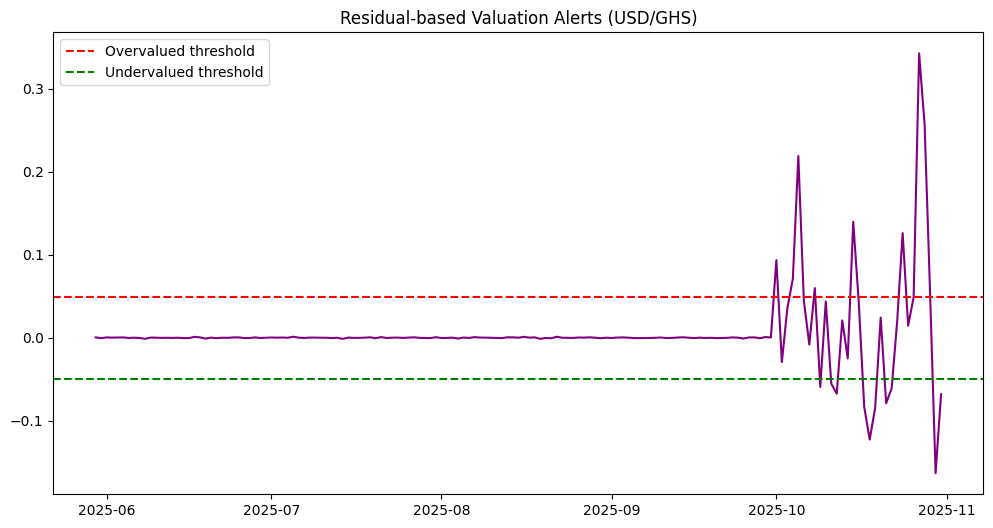

In [ ]:
# ============================================
# 4️⃣ AUTOMATED TREND ALERT SYSTEM
# ============================================

# --- Compute Residuals (Model Error) ---
# Use the refined model and features for prediction
df_refined_features['Predicted_USD_GHS'] = model_refined.predict(X_refined)
df_refined_features['Residual'] = df_refined_features['usd_ghs_rate'] - df_refined_features['Predicted_USD_GHS']

# --- Define Alert Thresholds ---
residual_std = df_refined_features['Residual'].std()
# Assuming 'volatility_7d' or 'volatility_30d' is the intended volatility column
# Assuming 'gold_price_usd' is the intended gold price column
vol_threshold = df_refined_features['volatility_7d'].std() * 1.5 # Using 7-day volatility as an example

# --- Generate Alerts ---
alerts = []

for i in range(len(df_refined_features)):
    row = df_refined_features.iloc[i]
    date = df_refined_features.index[i]
    alert = None

    # 1️⃣ Undervalued (GHS stronger than model predicts)
    if row['Residual'] < -residual_std:
        alert = f"{date.date()} 🔹 GHS may be *undervalued* — stronger than fundamentals imply."

    # 2️⃣ Overvalued (GHS weaker than model predicts)
    elif row['Residual'] > residual_std:
        alert = f"{date.date()} 🔸 GHS may be *overvalued* — weaker than fundamentals imply."

    # 3️⃣ Volatility surge
    # Using 'volatility_7d' as the metric
    elif abs(row['volatility_7d']) > vol_threshold:
        alert = f"{date.date()} ⚠️ High FX volatility detected."

    # 4️⃣ Gold-driven support
    # Using 'gold_price_usd' and its 7-day rolling mean from the refined features
    # Check if the rolling mean is available before using it
    gold_price_7d_avg = df_refined_features['gold_price_usd_7d_avg'].iloc[i] if 'gold_price_usd_7d_avg' in df_refined_features.columns else None

    if gold_price_7d_avg is not None and row['gold_price_usd'] > gold_price_7d_avg:
        alert = f"{date.date()} 💰 Gold strength may support GHS."
    elif gold_price_7d_avg is None:
         # Handle the case where the rolling mean feature wasn't created
         if row['gold_price_usd'] > df['gold_price_usd'].rolling(7).mean().iloc[i]: # Fallback to original df if possible
              alert = f"{date.date()} 💰 Gold strength may support GHS."


    if alert:
        alerts.append(alert)

# --- Display Recent Alerts ---
print("\n=== FX ALERT DASHBOARD ===")
for alert in alerts[-10:]:
    print(alert)

# --- Visualize Residuals ---
plt.figure(figsize=(12,6))
plt.plot(df_refined_features.index, df_refined_features['Residual'], color='purple')
plt.axhline(y=residual_std, color='red', linestyle='--', label='Overvalued threshold')
plt.axhline(y=-residual_std, color='green', linestyle='--', label='Undervalued threshold')
plt.title("Residual-based Valuation Alerts (USD/GHS)")
plt.legend()
plt.show()

In [ ]:
import dash
from dash import html, dcc
import plotly.express as px
import pandas as pd

# Load your enhanced dataset
# Use df_refined_features which contains the predicted values and is indexed by date
# df = pd.read_csv("ghs_currency_resilience_dataset.csv") # No longer need to load original df here for the dashboard

# Example feature importance DataFrame
importance_df = pd.DataFrame({
    'Feature': ['rate_momentum', 'gold_exports_volume', 'bop_current_account', 'fx_reserves_usd', 'dxy_index'],
    'Importance': [0.32, 0.28, 0.21, 0.12, 0.07]
})

# Example causality summary
causality_df = pd.DataFrame({
    'Variable': ['gold_exports_volume', 'bop_current_account', 'gold_price_usd', 'dxy_index'],
    'p_value': [0.0367, 0.0093, 0.9247, 0.2296]
})

# Initialize Dashboard
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("💹 GHS FX Intelligence Monitor", style={'textAlign': 'center'}),

    # KPI Cards
    html.Div([
        html.Div("R² Score: 0.7852", className="card green"),
        html.Div("MAE: 0.0826", className="card amber"),
        html.Div("Key Drivers: rate_momentum, gold_exports_volume, bop_current_account", className="card blue")
    ], style={'display': 'flex', 'justifyContent': 'space-around'}),

    # Feature Importance Chart
    html.Div([
        dcc.Graph(figure=px.bar(feature_importance_df_refined, x='Importance', y='Feature', orientation='h',
                                title="Feature Importance — Predictive Power (Refined Model)",
                                color='Importance', color_continuous_scale='Blues'))
    ]),

    # Causality Heatmap
    # Using the results from the multi-lag test for gold_exports_volume and bop_current_account
    html.Div([
        dcc.Graph(figure=px.imshow([causality_df['p_value']],
                                   labels=dict(x="Variable", y="Granger Causality p-value (Lag 3)"), # Label reflects the lag used in the original test
                                   x=causality_df['Variable'],
                                   y=['USD/GHS'], # Adding y-label for clarity
                                   color_continuous_scale='RdYlGn_r',
                                   title="Granger Causality Significance (p-values)"))
    ]),

    # Time-Series Chart - Using the refined features DataFrame
    html.Div([
        dcc.Graph(figure=px.line(df_refined_features, x=df_refined_features.index, y=['usd_ghs_rate', 'Predicted_USD_GHS'],
                                 title="USD/GHS Actual vs Predicted Trend",
                                 labels={'value': 'Exchange Rate', 'variable': 'Series', 'x': 'Date'})) # Update labels
    ])
])

# To run the Dash app in Colab, you typically need extra steps or libraries
# like jupyter-dash or colab-tunnel. For simplicity, we'll keep the basic structure.
# If you run this in a local environment with Dash installed, it will launch.

# if __name__ == "__main__":
#     app.run_server(debug=True)

# In Colab, you might use:
# from jupyter_dash import JupyterDash
# app = JupyterDash(__name__)
# ... (app layout as above) ...
# if __name__ == "__main__':
#     app.run_server(mode='inline', debug=True) # or mode='external'

In [ ]:
!pip install dash pandas plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 58.9 MB/s eta 0:00:00


After the installation is complete, please run the cell again.